# Programming assignment 1.5: Plotting in the clouds.

*[CEGM1000 MUDE](http://mude.citg.tudelft.nl/)*

*Written by: Patricia Mares Nasarre and Tom van Woudenberg*

*Due: `<day of week>`, `<month>` `<day>`, `<year>`.*

## Part 1: Introduction and set up of the model

In this programming assignment, you will work in creating plots in 3D and the projections of those plots in 2D using contours. These plotting tools are useful, for instance, when displaying the results of bivariate distribution.

Imagine you are a scientist interested in the atmospheric processes that lead to precipitation. You have been studying the relationship between the rain rate ($RR$, mm/h) and the ice content in the clouds ($IC$, kg/m2). You have determined that the bivariate distribution $F(RR, IC)$ is well described using a bivariate Gaussian distribution with the following parameters: $\mu_{RR} = 2.5$ mm/h and $\sigma_{RR}=2$ mm/h, $\mu_{IC} = 700$ kg/m2 and $\sigma_{IC}=300$ kg/m2, and $Cov(RR, IC)=300 \ mm/h \times kg/m2$.

In [2]:
import pandas as pd
import numpy as np
from scipy.stats import multivariate_normal
import matplotlib.pyplot as plt
from statistics import mean, stdev

<div style="background-color:#AABAB2; color: black; width:90%; vertical-align: middle; padding:15px; margin: 10px; border-radius: 10px">
<p>

$\text{Task 1.1:}$
    
Define a bivariate Gaussian distribution between $RR$ and $IC$ given the above information. Draw 100 random samples from the defined distribution and plot them.

Follow the following steps:
- Define the vector of means
- Define the covariance matrix
- Define the bivariate Gaussian distribution and draw 100 samples.
</p>
</div>

In [ ]:
# Define the vector of means
mu1 = ### YOUR CODE HERE ###
mu2 = ### YOUR CODE HERE ###
mu = [mu1, mu2] #vector of means

# Define the covariance matrix
s1 = ### YOUR CODE HERE ###
s2 = ### YOUR CODE HERE ###
covariance = ### YOUR CODE HERE ###
sigma = ### YOUR CODE HERE ###

# Draw 100 samples from a bivariate Gaussian distribution
samples = multivariate_normal(mean=mu, cov=sigma).rvs(size=100)

# Scatter plot against observations
### YOUR CODE LINES HERE

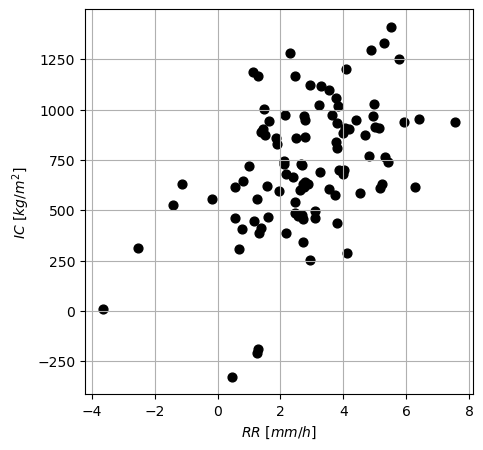

In [3]:
# Define the vector of means
mu1 = 2.5 #mu_1
mu2 = 700 #mu_2
mu = [mu1, mu2] #vector of means

# Define the covariance matrix
s1 = 2  #sigma_x1
s2 = 300  #sigma_x2
covariance = 300 #correlation coefficient
sigma = np.array([[s1**2 , covariance], [covariance, s2**2]]) #Covariance matrix

# Draw 100 samples from a bivariate Gaussian distribution
samples = multivariate_normal(mean=mu, cov=sigma).rvs(size=100)

# Scatter plot against observations
fig, axs = plt.subplots(1, 1)
axs.scatter(samples[:,0], samples[:,1], 40, 'k')
axs.set_ylabel('${IC} \ [kg/m^2]$')
axs.set_xlabel('${RR} \ [mm/h]$')
fig.set_size_inches(5, 5)
axs.grid()

<div style="background-color:#FAE99E; color: black; vertical-align: middle; padding:15px; margin: 10px; border-radius: 10px; width: 90%">

$\text{Solution 1.1:}$

Note that negative values of $RR$ are obtained using the model, although they do not have physical sense.
</p></div>

## Part 2. 3D plots

In order to create 3D plots, we usually need to evaluate a function over a 2D grid. To do so, we can use the function `np.meshgrid` which takes two 1D arrays of values (usually representing axes x and y) and turns them into 2D grids, so you can evaluate functions over a grid of (x, y) points.

Let's see it with an example!

Imagine that I want to calculate $Z$ as function of $A$ and $B$, $Z = f(A, B)$, and plot it spatially. Thus, $A$ and $B$ are the axis x and y, while $Z$ is the z-axis. We need to generate a grid with values of $A$ and $B$ to evaluate $Z$. We can do it as follows:

In [19]:
# Define the range of values for A and B
n = 5 #number of values or size of the mesh
values_A = np.linspace(0,30,n)
values_B = np.linspace(-5, 5,n)

# Define the grid
A2,B2 = np.meshgrid(values_A,values_B)

print(f"The values to evaluate A are: {values_A}")
print(f"The grid defined for A is: {A2}")
print(f"The grid defined for B is: {B2}")

The values to evaluate A are: [ 0.   7.5 15.  22.5 30. ]
The grid defined for A is: [[ 0.   7.5 15.  22.5 30. ]
 [ 0.   7.5 15.  22.5 30. ]
 [ 0.   7.5 15.  22.5 30. ]
 [ 0.   7.5 15.  22.5 30. ]
 [ 0.   7.5 15.  22.5 30. ]]
The grid defined for B is: [[-5.  -5.  -5.  -5.  -5. ]
 [-2.5 -2.5 -2.5 -2.5 -2.5]
 [ 0.   0.   0.   0.   0. ]
 [ 2.5  2.5  2.5  2.5  2.5]
 [ 5.   5.   5.   5.   5. ]]


In the above prints, you can see that the values where we wanted to evaluate A have been repeated 5 times in rows while the values where we wanted to evaluate B have been repeated 5 times in columns to create a grid. This allows to cover all the combinations of values of A and B.

In order to move back from that grid to a 2d array with all the combinations of $A$ and $B$, we can use `np.concatenate` to transform both A2 and B2 into a 1D array. Afterwards, it is possible to join them in a single array. 

In [23]:
A2_1d = np.concatenate(A2.T)
print(A2_1d)

[ 0.   0.   0.   0.   0.   7.5  7.5  7.5  7.5  7.5 15.  15.  15.  15.
 15.  22.5 22.5 22.5 22.5 22.5 30.  30.  30.  30.  30. ]


<div style="background-color:#AABAB2; color: black; width:90%; vertical-align: middle; padding:15px; margin: 10px; border-radius: 10px">
<p>

$\text{Task 2.1:}$

Using the defined bivariate Gaussian distribution, compute and plot the bivariate PDF as a 3D plot where the x- and y-axis are the values of $RR$ and $IC$ and the z-axis are the densities.
</p>
</div>

*Hint 1: Use the function meshgrid of numpy to define a grid to evaluate the PDF.*

*Hint 2: use plot_surface of matplotlib to display the 3D plot.*

In [ ]:
# Define the mesh of values where we want to evaluate the random variables
n = 200 #size of the mesh
values_RR = np.linspace(### YOUR CODE HERE ###)
values_IC = np.linspace(### YOUR CODE HERE ###)

# Define the grid
X1,X2 = np.meshgrid(### YOUR CODE HERE ###)
X = ### YOUR CODE HERE ###

# Evaluate the PDF
Z = multivariate_normal(mean=mu, cov=sigma).pdf(X)

# Create the 3D plot
### YOUR CODE LINES HERE

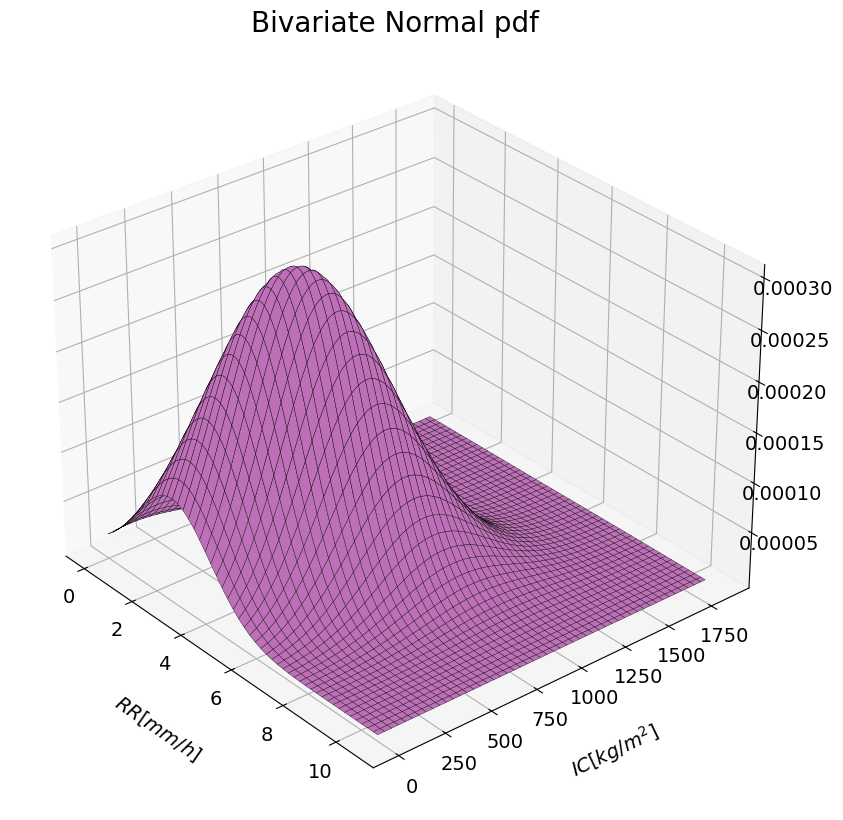

In [8]:
# Define the mesh of values where we want to evaluate the random variables
n = 200 #size of the mesh
values_RR = np.linspace(0,mu[0]+3.8*s1,n)
values_IC = np.linspace(0,mu[1]+3.8*s2,n)

# Define the grid
X1,X2 = np.meshgrid(values_RR,values_IC)
X = np.array([np.concatenate(X1.T), np.concatenate(X2.T)]).T

# Evaluate the PDF
Z = multivariate_normal(mean=mu, cov=sigma).pdf(X)

# Create the 3D plot
plt.rcParams.update({'font.size': 14})
fig = plt.figure(figsize=(15,10))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X1, X2, Z.reshape(X1.shape), color='#F792EF', edgecolor='black', linewidth=.25)
ax.set_xlabel('${RR} [mm/h]$',labelpad=20)
ax.set_ylabel('${IC} [kg/m^2]$',labelpad=20)
ax.set_zlabel('$f(x_1,x_2)$',labelpad=20)
ax.set_title(f'Bivariate Normal pdf', fontsize=20)
ax.view_init(ax.elev, ax.azim+20)
plt.show()

<div style="background-color:#AABAB2; color: black; width:90%; vertical-align: middle; padding:15px; margin: 10px; border-radius: 10px">
<p>

$\text{Task 2.2:}$

Using the defined bivariate Gaussian distribution, compute and plot the bivariate PDF as contours where densities are projected. This is, the x- and y-axis are the values of $RR$ and $IC$ and the contours in the plot represent values of densities.
</p>
</div>

*Hint 1: you can reuse the grid defined in the previous task.*

*Hint 2: use contour of matplotlib to draw the contours.*

In [ ]:
### YOUR CODE LINES HERE

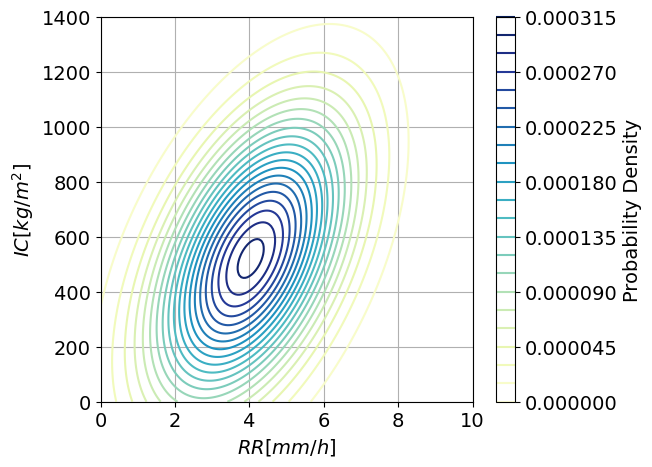

In [13]:
# Create contours plot
fig = plt.figure(figsize=(6,5))
ax = fig.add_subplot(111)
contours = ax.contour(X1, X2, Z.reshape(X1.shape), 25, cmap='YlGnBu', vmin=0)
ax.grid()
ax.set_xlim([0, 10])
ax.set_ylim([0, 1400])
ax.set_xlabel('${RR} [mm/h]$')
ax.set_ylabel('${IC} [kg/m^2]$')
fig.colorbar(contours, ax=ax, label='Probability Density')

<div style="background-color:#FAE99E; color: black; vertical-align: middle; padding:15px; margin: 10px; border-radius: 10px; width: 90%">
<p>
End of solution.
</p>
</div>

<div style="margin-top: 50px; padding-top: 20px; border-top: 1px solid #ccc;">
  <div style="display: flex; justify-content: flex-end; gap: 20px; align-items: center;">
    <a rel="MUDE" href="http://mude.citg.tudelft.nl/">
      <img alt="MUDE" style="width:100px; height:auto;" src="https://gitlab.tudelft.nl/mude/public/-/raw/main/mude-logo/MUDE_Logo-small.png" />
    </a>
    <a rel="TU Delft" href="https://www.tudelft.nl/en/ceg">
      <img alt="TU Delft" style="width:100px; height:auto;" src="https://gitlab.tudelft.nl/mude/public/-/raw/main/tu-logo/TU_P1_full-color.png" />
    </a>
    <a rel="license" href="http://creativecommons.org/licenses/by/4.0/">
      <img alt="Creative Commons License" style="width:88px; height:auto;" src="https://i.creativecommons.org/l/by/4.0/88x31.png" />
    </a>
  </div>
  <div style="font-size: 75%; margin-top: 10px; text-align: right;">
    &copy; Copyright 2025 <a rel="MUDE" href="http://mude.citg.tudelft.nl/">MUDE</a> TU Delft. 
    This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by/4.0/">CC BY 4.0 License</a>.
  </div>
</div>